In [1]:
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

from glob import glob

In [2]:
df = pd.DataFrame( columns=['X', 'Y', 'Z', "E"] )

e = 20.0
t = "F_IN_FE"

samples = { "X": [], "Y": [], "Z": [], "E": [] }

for file in glob( "out/RANGE_{}_ENERGY_{}KEV*".format( t, e ) ):
    
    with open( file, encoding = "ISO-8859-1" ) as f:
        Lines = f.readlines( )
        for line in Lines:
            l = line.split( )
            if( len( l ) == 4 and l[ 0 ].isdigit( ) ):
                samples[ "X" ].append( float( l[ 1 ] ) * 1e-1 )
                samples[ "Y" ].append( float( l[ 2 ] ) * 1e-1 )
                samples[ "Z" ].append( float( l[ 3 ] ) * 1e-1 )
                samples[ "E" ].append( e )

df = pd.concat( [ df, pd.DataFrame( samples ) ] )

e = 40.0
t = "F_IN_FE"

samples = { "X": [], "Y": [], "Z": [], "E": [] }

for file in glob( "out/RANGE_{}_ENERGY_{}KEV*".format( t, e ) ):
    
    with open( file, encoding = "ISO-8859-1" ) as f:
        Lines = f.readlines( )
        for line in Lines:
            l = line.split( )
            if( len( l ) == 4 and l[ 0 ].isdigit( ) ):
                samples[ "X" ].append( float( l[ 1 ] ) * 1e-1 )
                samples[ "Y" ].append( float( l[ 2 ] ) * 1e-1 )
                samples[ "Z" ].append( float( l[ 3 ] ) * 1e-1 )
                samples[ "E" ].append( e )

df = pd.concat( [ df, pd.DataFrame( samples ) ] )

/tmp/ipykernel_3312219/966000901.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat( [ df, pd.DataFrame( samples ) ] )


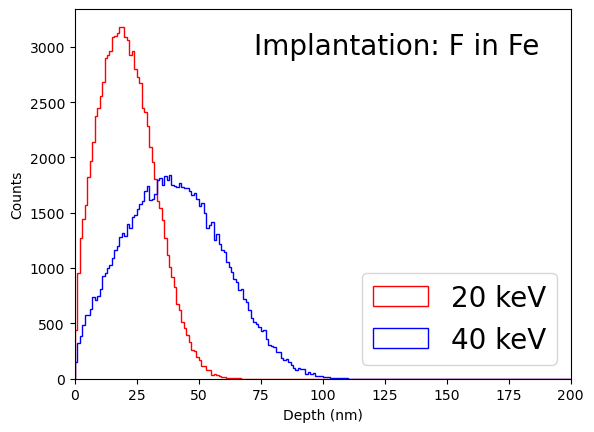

In [3]:
fig, ax = plt.subplots( )

mask = (df[ "E" ] == 20.0)
ax.hist( df[mask]["X"], bins = 200, range=(0,200), histtype = "step", color="red", label="20 keV")

mask = (df[ "E" ] == 40.0)
ax.hist( df[mask]["X"], bins = 200, range=(0,200), histtype = "step", color="blue", label="40 keV")

ax.text( 0.65, 0.9, "Implantation: F in Fe", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=20 )

ax.set_xlabel( "Depth (nm)" )
ax.set_ylabel( "Counts" )

ax.set_xlim( 0, 200 )

ax.legend( loc="lower right", fontsize=20 )

plt.savefig( "plots/{}_{}KEV.png".format( t, e ), dpi=300, bbox_inches='tight' )
plt.show( )

In [4]:
df = pd.DataFrame( columns=['X', 'Y', 'Z', "E"] )

e = 20.0
t = "F_IN_FE"

samples = { "X": [], "Y": [], "Z": [], "E": [] }

idx = 0
for file in glob( "out/RANGE_{}_ENERGY_{}KEV*".format( t, e ) ):
    
    if( idx > 20 ): continue
    idx += 1

    with open( file, encoding = "ISO-8859-1" ) as f:
        Lines = f.readlines( )
        for line in Lines:
            l = line.split( )
            if( len( l ) == 4 and l[ 0 ].isdigit( ) ):
                samples[ "X" ].append( float( l[ 1 ] ) * 1e-1 )
                samples[ "Y" ].append( float( l[ 2 ] ) * 1e-1 )
                samples[ "Z" ].append( float( l[ 3 ] ) * 1e-1 )
                samples[ "E" ].append( e )

df = pd.concat( [ df, pd.DataFrame( samples ) ] )

e = 40.0
t = "F_IN_FE"

samples = { "X": [], "Y": [], "Z": [], "E": [] }

idx = 0
for file in glob( "out/RANGE_{}_ENERGY_{}KEV*".format( t, e ) ):

    if( idx > 100 ): continue
    idx += 1
    
    with open( file, encoding = "ISO-8859-1" ) as f:
        Lines = f.readlines( )
        for line in Lines:
            l = line.split( )
            if( len( l ) == 4 and l[ 0 ].isdigit( ) ):
                samples[ "X" ].append( float( l[ 1 ] ) * 1e-1 )
                samples[ "Y" ].append( float( l[ 2 ] ) * 1e-1 )
                samples[ "Z" ].append( float( l[ 3 ] ) * 1e-1 )
                samples[ "E" ].append( e )

df = pd.concat( [ df, pd.DataFrame( samples ) ] )

/tmp/ipykernel_3312219/1255832586.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat( [ df, pd.DataFrame( samples ) ] )


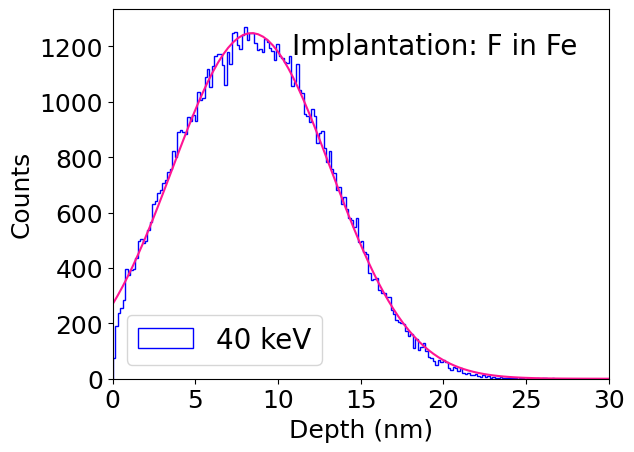

In [46]:
plt.matplotlib.rcParams.update({'font.size': 18})

fig, ax = plt.subplots( )

# mask = (df[ "E" ] == 20.0)
# ax.hist( df[mask]["X"] * 2.185e-1, bins = 200, range=(0,30), histtype = "step", color="red", label="20 keV", ls="--")

mask = (df[ "E" ] == 40.0)
ax.hist( df[mask]["X"] * 2.185e-1, bins = 200, range=(0,30), histtype = "step", color="blue", label="40 keV", ls="--")

# ax.hist( df["X"] * 2.185e-1, bins = 200, range=(0,30), histtype = "step", color="black", label="Sum")

ax.text( 0.65, 0.9, "Implantation: F in Fe", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=20 )

from scipy.optimize import curve_fit

def gaussian(x, amp, mean, sigma):
    return (amp/np.sqrt(2*np.pi*sigma**2)) * np.exp(-0.5*((x-mean)/sigma)**2)

# Plot a gaussian at 4.5 with sigma 6.5
mean, sigma = 8.4, 4.9
x = np.linspace(0, 30, 100)
y = gaussian(x, 1, mean, sigma)

# Fit hist data with gaussian
hist_data, bin_edges = np.histogram( df[mask]["X"] * 2.185e-1, bins = 200, range=(0,30) )
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
popt, pcov = curve_fit(gaussian, bin_centers, hist_data, p0=[max(hist_data), mean, sigma])
# Generate fitted curve

y_fit = gaussian(x, *popt)
plt.plot(x, y_fit, color="deeppink")

# Scale it to the max of the histogram
y = y * (ax.get_ylim()[1] / max(y)) / 1.1

# ax.plot(x, y, color="deeppink")

ax.set_xlabel( "Depth (nm)" )
ax.set_ylabel( "Counts" )

ax.set_xlim( 0, 30 )

ax.legend( fontsize=20 )

plt.savefig( "plots/{}_{}KEV.png".format( t, e ), dpi=300, bbox_inches='tight' )
plt.show( )